In [1]:
1+1

2

# Chain Using LangGraph

In this section we will see how we can build a simple chain using LangGraph that uses 4 important concepts:

* How to use chat messages as our graph state
* How to use chat models in graph nodes
* How to bind tools to our LLM in chat models
* How to execute the tools call in our graph nodes


In [3]:
from dotenv import load_dotenv
load_dotenv()

import os 
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

# How to use chat messages as our graph state

## Messages

We can use messages which can be used to capture different roles within a conversation. LangChain has various message types including HumanMessage, AIMessage, SystemMessage and ToolMessage. These represent a message from the user, from chat model, for the chat model to instruct behavior, and from a tool call.

Every message have these important components.

* **content** - content of the message
* **name** - Specify the name of author
* **response_metadata** - optionally, a dict of metadata (e.g., often populated by model provider for AIMessages)


In [4]:
from langchain_core.messages import AIMessage,HumanMessage
from pprint import pprint 

messages = [AIMessage(content=f"Please tell me how can I help",name="LLMModel")]
messages.append(HumanMessage(content=f"I want to learn coding",name="Teja"))
messages.append(AIMessage(content=f"Which programming language you want to learn",name="LLMModel"))
messages.append(HumanMessage(content=f"I want to learn Python programming language",name="Teja"))

for message in messages:
    message.pretty_print()

================================== Ai Message ==================================
Name: LLMModel

Please tell me how can I help
================================ Human Message =================================
Name: Teja

I want to learn coding
================================== Ai Message ==================================
Name: LLMModel

Which programming language you want to learn
================================ Human Message =================================
Name: Teja

I want to learn Python programming language


# Chat Models

We can use the sequence of messages as input with the chat models using LLMs and OpenAI.


In [5]:
from langchain_groq import ChatGroq
llm = ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct")
result = llm.invoke(messages)

In [6]:
result.content

'Python is a great language to learn. Here are some steps to get you started:\n\n**Step 1: Get Familiar with Python Basics**\n\n* Start with basic syntax and data types: variables, strings, lists, tuples, dictionaries, etc.\n* Understand indentation and block-level structure\n\n**Step 2: Choose a Resource to Learn**\n\n* Online courses:\n\t+ Codecademy (interactive coding environment)\n\t+ Coursera (Python courses from top universities)\n\t+ edX (Python courses from top universities)\n* Books:\n\t+ "Python Crash Course" by Eric Matthes\n\t+ "Automate the Boring Stuff with Python" by Al Sweigart\n* YouTube channels:\n\t+ Corey Schafer\'s Python Tutorials\n\t+ Traversy Media (Brad Traversy\'s Python tutorials)\n\n**Step 3: Set Up a Development Environment**\n\n* Install Python on your computer (if you haven\'t already)\n* Choose a text editor or IDE (Integrated Development Environment):\n\t+ PyCharm\n\t+ Visual Studio Code\n\t+ Sublime Text\n\t+ Atom\n\n**Step 4: Practice and Build Proje

In [7]:
result.response_metadata

{'token_usage': {'completion_tokens': 366,
  'prompt_tokens': 51,
  'total_tokens': 417,
  'completion_time': 0.828135231,
  'completion_tokens_details': None,
  'prompt_time': 0.000278515,
  'prompt_tokens_details': None,
  'queue_time': 0.046784634,
  'total_time': 0.828413746},
 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct',
 'system_fingerprint': 'fp_79da0e0073',
 'service_tier': 'on_demand',
 'finish_reason': 'stop',
 'logprobs': None,
 'model_provider': 'groq'}

### Tools

Tools can be integrated with the LLM models to interact with external systems. External systems can be APIs or third-party tools.

Whenever a query is asked, the model can choose to call the tool. The query is interpreted from the natural-language input, and the tool returns an output that matches the tool's schema.

In [8]:
def add(a:int,b:int)->int:
    """
    Add a and b
    Args:
        a(int) : first int
        b(int) : second int
    Returns:
        int
    """
    return a + b

In [9]:
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000029963483110>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000029963483B10>, model_name='meta-llama/llama-4-scout-17b-16e-instruct', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [12]:
## Binding tools with LLM 
llm_with_tools = llm.bind_tools([add])

tool_call = llm_with_tools.invoke([HumanMessage(content=f"Hey what is 2 plus 2",name="Teja")])

In [13]:
tool_call.tool_calls

[{'name': 'add',
  'args': {'a': 2, 'b': 2},
  'id': 'h4q3h0g3f',
  'type': 'tool_call'}]

### Using messages as states

In [14]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage

class State(TypedDict):
    message:list[AnyMessage]
    

####Reducers

Now, we have a minor problem!

As we discussed, each node will return a new value for our state key messages.

But, this new value will override the prior messages value.

As our graph runs, we want to append messages to our messages state key.

We can use reducer functions to address this.

Reducers allow us to specify how state updates are performed.

If no reducer function is specified, then it is assumed that updates to the key should override it as we saw before.

But, to append messages, we can use the pre-built add_messages reducer.

This ensures that any messages are appended to the existing list of messages.

We simply need to annotate our messages key with the add_messages reducer function as metadata.

In [30]:
from langgraph.graph.message import add_messages
from typing import Annotated

class State(TypedDict):
    messages:Annotated[list,add_messages]
    

### Reducers with add_messages


In [31]:
initial_messages = [AIMessage(content=f"Please tell me how can I help",name="LLMModel")]
initial_messages.append(HumanMessage(content=f"I want to learn coding",name="Teja"))
initial_messages

[AIMessage(content='Please tell me how can I help', additional_kwargs={}, response_metadata={}, name='LLMModel', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I want to learn coding', additional_kwargs={}, response_metadata={}, name='Teja')]

In [32]:
ai_message = AIMessage(content=f"Which programming language you want to learn",name="LLMModel")
ai_message

AIMessage(content='Which programming language you want to learn', additional_kwargs={}, response_metadata={}, name='LLMModel', tool_calls=[], invalid_tool_calls=[])

In [33]:
## Reducer add_message is used to append instead of overiding
add_messages(initial_messages,ai_message)

[AIMessage(content='Please tell me how can I help', additional_kwargs={}, response_metadata={}, name='LLMModel', id='6b3a3b53-e732-49d9-8223-81a6a09d56e8', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I want to learn coding', additional_kwargs={}, response_metadata={}, name='Teja', id='c57b6fb0-3ba9-4ae1-be60-11f8e265a336'),
 AIMessage(content='Which programming language you want to learn', additional_kwargs={}, response_metadata={}, name='LLMModel', id='1d7ad5e3-23b2-47b2-b11e-f4dc0124d6ef', tool_calls=[], invalid_tool_calls=[])]

In [39]:
## Chat bot node functionality

def llm_tool(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

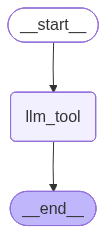

In [40]:
from IPython.display import display,Image 
from langgraph.graph import StateGraph,START,END

builder = StateGraph(State)

builder.add_node("llm_tool",llm_tool)
builder.add_edge(START,"llm_tool")
builder.add_edge("llm_tool",END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [42]:
## invocation

messages = graph.invoke({"messages":"what is 2 Plus 2"})

for message in messages["messages"]:
    message.pretty_print()


================================ Human Message =================================

what is 2 Plus 2
================================== Ai Message ==================================
Tool Calls:
  add (g8q18csx3)
 Call ID: g8q18csx3
  Args:
    a: 2
    b: 2


In [44]:
tools = [add]

In [45]:
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

builder = StateGraph(State)

## Add the nodes 
builder.add_node("llm_tool",llm_tool)
builder.add_node("tools",ToolNode(tools))

builder.add_edge(START,"llm_tool")
builder.add_conditional_edges(
    "llm_tool",
    tools_condition
)
builder.add_edge("tools",END)

graph_builder = builder.compile()



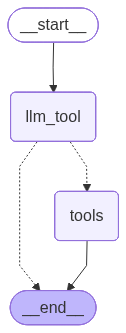

In [46]:
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [47]:
## invocation

messages = graph.invoke({"messages":"what is 2 Plus 2"})

for message in messages["messages"]:
    message.pretty_print()


================================ Human Message =================================

what is 2 Plus 2
================================== Ai Message ==================================
Tool Calls:
  add (ye1n0fvde)
 Call ID: ye1n0fvde
  Args:
    a: 2
    b: 2
